In [1]:
!wget -q https://www.kaggle.com/api/v1/datasets/download/mlg-ulb/creditcardfraud -O dataset.zip
!unzip -q dataset.zip -d dataset

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [2]:
import os

print("Files in dataset folder:")
print(os.listdir("dataset"))

Files in dataset folder:
['creditcard.csv']


In [3]:
!rm -rf dataset dataset.zip

!wget -q https://www.kaggle.com/api/v1/datasets/download/rikdifos/credit-card-approval-prediction -O dataset.zip
!unzip -q dataset.zip -d dataset

import os
print("Files downloaded:")
print(os.listdir("dataset"))

Files downloaded:
['application_record.csv', 'credit_record.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
app = pd.read_csv('/content/dataset/application_record.csv')
credit = pd.read_csv('/content/dataset/credit_record.csv')

print("Application Dataset Shape:", app.shape)
print("Credit Dataset Shape:", credit.shape)

display(app.head())
display(credit.head())

Application Dataset Shape: (438557, 18)
Credit Dataset Shape: (1048575, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


Occupation Type Counts:
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


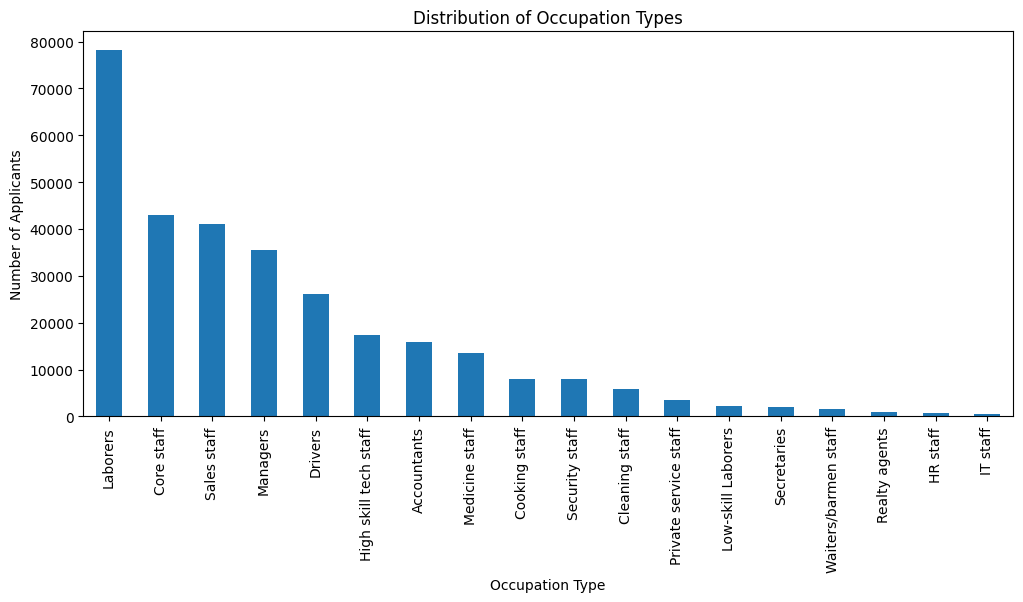

In [6]:
print("Occupation Type Counts:")
print(app['OCCUPATION_TYPE'].value_counts())

app['OCCUPATION_TYPE'].value_counts().plot(kind='bar', figsize=(12, 5))
plt.title("Distribution of Occupation Types")
plt.xlabel("Occupation Type")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=90)
plt.show()

In [7]:
print("Descriptive Statistics:")
display(app.describe())

Descriptive Statistics:


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


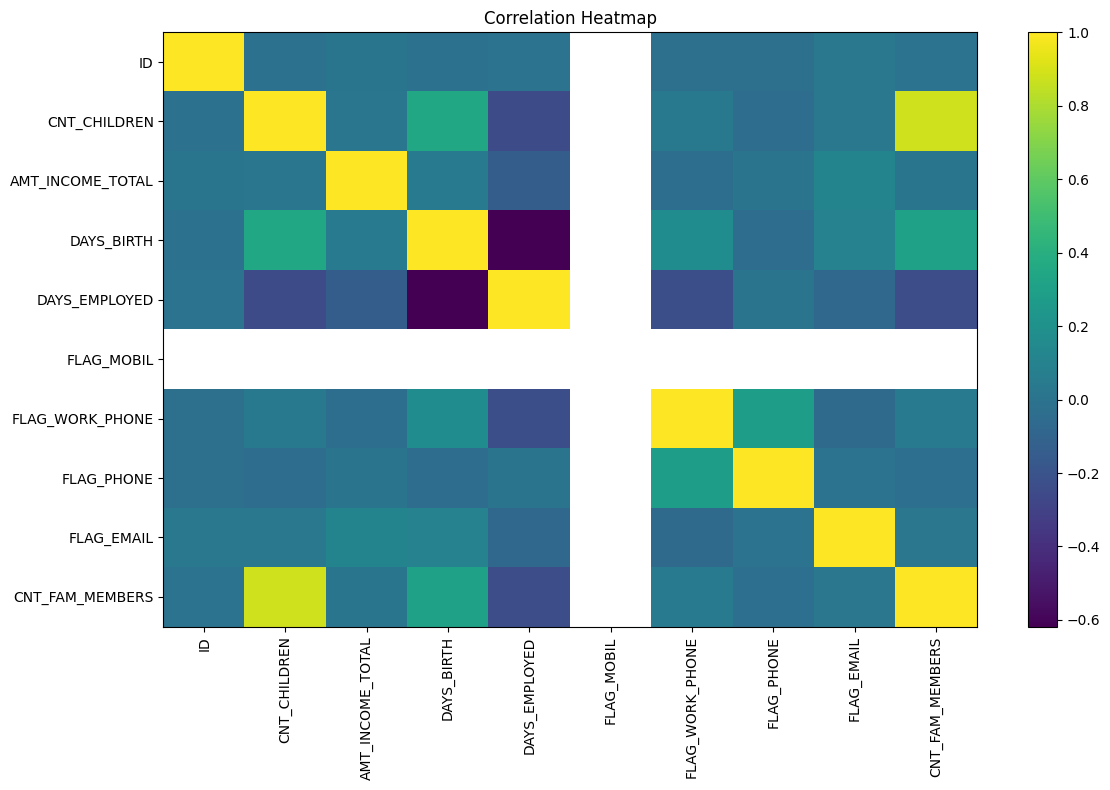

In [8]:
numeric_data = app.select_dtypes(include=np.number)

correlation = numeric_data.corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation, aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [9]:
# Remove duplicate applicant records
app = app.drop_duplicates(subset='ID', keep='first')

print("Application dataset shape after removing duplicates:", app.shape)

print("\nMissing Values:")
print(app.isnull().sum())

print("\nMissing Value Percentage:")
print(app.isnull().mean() * 100)

Application dataset shape after removing duplicates: (438510, 18)

Missing Values:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134193
CNT_FAM_MEMBERS             0
dtype: int64

Missing Value Percentage:
ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BI

In [10]:
# Fill missing occupation values
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].fillna('Unknown')

# Convert negative day values to positive
app['DAYS_BIRTH'] = abs(app['DAYS_BIRTH'])
app['DAYS_EMPLOYED'] = abs(app['DAYS_EMPLOYED'])

# Create age and employment year features
app['AGE'] = (app['DAYS_BIRTH'] / 365).astype(int)
app['YEARS_EMPLOYED'] = (app['DAYS_EMPLOYED'] / 365).astype(int)

# Create total family dependency feature
app['TOTAL_FAMILY'] = app['CNT_CHILDREN'] + app['CNT_FAM_MEMBERS']

print("Feature engineering completed successfully!")

display(app.head())

Feature engineering completed successfully!


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TOTAL_FAMILY
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542,1,1,0,0,Unknown,2.0,32,12,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542,1,1,0,0,Unknown,2.0,32,12,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1134,1,0,0,0,Security staff,2.0,58,3,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,3051,1,0,1,1,Sales staff,1.0,52,8,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,3051,1,0,1,1,Sales staff,1.0,52,8,1.0


In [11]:
# Convert credit status into binary target

def convert_status(status):
    if status in ['0', '1', '2', '3', '4', '5']:
        return 0
    else:
        return 1

credit['TARGET'] = credit['STATUS'].apply(convert_status)

print("Target distribution:")
print(credit['TARGET'].value_counts())

Target distribution:
TARGET
1    651261
0    397314
Name: count, dtype: int64


In [12]:
credit_summary = credit.groupby('ID')['TARGET'].min().reset_index()

print("Credit summary created successfully!")
display(credit_summary.head())

Credit summary created successfully!


,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,1
3,5001714,1
4,5001715,1


In [13]:
data = pd.merge(app, credit_summary, on='ID', how='inner')

print("Datasets merged successfully!")
print("Final dataset shape:", data.shape)

display(data.head())

Datasets merged successfully!
Final dataset shape: (36457, 22)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TOTAL_FAMILY,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,32,12,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,32,12,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,58,3,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52,8,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52,8,1.0,1


In [14]:
# Remove unnecessary columns
data = data.drop(columns=['ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED'])

# Convert categorical columns into numerical values
categorical_columns = data.select_dtypes(include=['object']).columns

data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

print("Categorical encoding completed!")
print("Final dataset shape:", data.shape)

display(data.head())

Categorical encoding completed!
Final dataset shape: (36457, 49)


,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TOTAL_FAMILY,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,0,427500.0,1,1,0,0,2.0,32,12,2.0,...,False,False,False,False,False,False,False,False,True,False
1,0,427500.0,1,1,0,0,2.0,32,12,2.0,...,False,False,False,False,False,False,False,False,True,False
2,0,112500.0,1,0,0,0,2.0,58,3,2.0,...,False,False,False,False,False,False,False,True,False,False
3,0,270000.0,1,0,1,1,1.0,52,8,1.0,...,False,False,False,False,False,True,False,False,False,False
4,0,270000.0,1,0,1,1,1.0,52,8,1.0,...,False,False,False,False,False,True,False,False,False,False


In [15]:
X = data.drop('TARGET', axis=1)
y = data['TARGET']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

X Shape: (36457, 48)
y Shape: (36457,)

Target Distribution:
TARGET
0    32002
1     4455
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split successfully!")

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

Data split successfully!
X_train Shape: (29165, 48)
X_test Shape: (7292, 48)
y_train Shape: (29165,)
y_test Shape: (7292,)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.8778113000548546

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      6401
           1       0.00      0.00      0.00       891

    accuracy                           0.88      7292
   macro avg       0.44      0.50      0.47      7292
weighted avg       0.77      0.88      0.82      7292



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8854909489851892

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      6401
           1       0.55      0.34      0.42       891

    accuracy                           0.89      7292
   macro avg       0.73      0.65      0.68      7292
weighted avg       0.87      0.89      0.87      7292



In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8824739440482721

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      6401
           1       0.53      0.33      0.41       891

    accuracy                           0.88      7292
   macro avg       0.72      0.64      0.67      7292
weighted avg       0.86      0.88      0.87      7292



In [20]:
import pickle

log_accuracy = accuracy_score(y_test, log_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Logistic Regression Accuracy:", log_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

models = {
    "Logistic Regression": (log_model, log_accuracy),
    "Random Forest": (rf_model, rf_accuracy),
    "Decision Tree": (dt_model, dt_accuracy)
}

best_model_name = max(models, key=lambda x: models[x][1])
best_model = models[best_model_name][0]

print("\nBest Model:", best_model_name)

with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

with open("model_columns.pkl", "wb") as file:
    pickle.dump(list(X.columns), file)

print("Best model saved as model.pkl")
print("Model columns saved as model_columns.pkl")

Logistic Regression Accuracy: 0.8778113000548546
Random Forest Accuracy: 0.8854909489851892
Decision Tree Accuracy: 0.8824739440482721

Best Model: Random Forest
Best model saved as model.pkl
Model columns saved as model_columns.pkl


In [21]:
!pip install flask pyngrok -q

print("Flask and pyngrok installed successfully!")

Flask and pyngrok installed successfully!


In [22]:
import os

os.makedirs("templates", exist_ok=True)

print("Templates folder created successfully!")

Templates folder created successfully!


In [23]:
home_html = """
<!DOCTYPE html>
<html>
<head>
    <title>Credit Card Approval Prediction</title>
</head>
<body style="text-align:center; font-family:Arial; padding-top:100px;">

    <h1>Credit Card Approval Prediction</h1>

    <p>Predict whether a credit card application will be approved.</p>

    <a href="/predict">
        <button style="padding:12px 25px; font-size:18px;">
            Start Prediction
        </button>
    </a>

</body>
</html>
"""

with open("templates/home.html", "w") as file:
    file.write(home_html)

print("home.html created successfully!")

home.html created successfully!


In [24]:
index_html = """
<!DOCTYPE html>
<html>
<head>
    <title>Credit Card Approval Prediction</title>
</head>

<body style="font-family:Arial; text-align:center;">

<h1>Credit Card Approval Prediction</h1>

<form action="/submit" method="POST">

    <label>Gender:</label><br>
    <select name="gender">
        <option value="M">Male</option>
        <option value="F">Female</option>
    </select>

    <br><br>

    <label>Own Car:</label><br>
    <select name="car">
        <option value="Y">Yes</option>
        <option value="N">No</option>
    </select>

    <br><br>

    <label>Own Property:</label><br>
    <select name="property">
        <option value="Y">Yes</option>
        <option value="N">No</option>
    </select>

    <br><br>

    <label>Number of Children:</label><br>
    <input type="number" name="children" required>

    <br><br>

    <label>Annual Income:</label><br>
    <input type="number" name="income" required>

    <br><br>

    <label>Age:</label><br>
    <input type="number" name="age" required>

    <br><br>

    <label>Years Employed:</label><br>
    <input type="number" name="employment" required>

    <br><br>

    <label>Family Members:</label><br>
    <input type="number" name="family" required>

    <br><br>

    <button type="submit">Predict</button>

</form>

</body>
</html>
"""

with open("templates/index.html", "w") as file:
    file.write(index_html)

print("index.html created successfully!")

index.html created successfully!


In [25]:
result_html = """
<!DOCTYPE html>
<html>
<head>
    <title>Prediction Result</title>
</head>

<body style="font-family:Arial; text-align:center; padding-top:100px;">

    <h1>Credit Card Approval Prediction</h1>

    <h2>{{ prediction_text }}</h2>

    <br>

    <a href="/predict">
        <button style="padding:10px 20px;">
            Make Another Prediction
        </button>
    </a>

    <br><br>

    <a href="/">
        Back to Home
    </a>

</body>
</html>
"""

with open("templates/result.html", "w") as file:
    file.write(result_html)

print("result.html created successfully!")

result.html created successfully!


In [27]:
app_code = """
from flask import Flask, render_template, request
import pandas as pd
import pickle

app = Flask(__name__)

# Load trained model and feature columns
with open("model.pkl", "rb") as file:
    model = pickle.load(file)

with open("model_columns.pkl", "rb") as file:
    model_columns = pickle.load(file)


@app.route("/")
def home():
    return render_template("home.html")


@app.route("/predict")
def predict_page():
    return render_template("index.html")


@app.route("/submit", methods=["POST"])
def submit():

    # Create empty input with exactly the same columns used during training
    input_data = pd.DataFrame(
        0,
        index=[0],
        columns=model_columns
    )

    # Get values from HTML form
    gender = request.form["gender"]
    car = request.form["car"]
    property_value = request.form["property"]

    children = float(request.form["children"])
    income = float(request.form["income"])
    age = float(request.form["age"])
    employment = float(request.form["employment"])
    family = float(request.form["family"])

    # Set numerical values only if the columns exist
    values = {
        "CNT_CHILDREN": children,
        "AMT_INCOME_TOTAL": income,
        "AGE": age,
        "YEARS_EMPLOYED": employment,
        "CNT_FAM_MEMBERS": family,
        "TOTAL_FAMILY": children + family
    }

    for column, value in values.items():
        if column in input_data.columns:
            input_data.loc[0, column] = value

    # Set categorical one-hot encoded values
    categorical_values = [
        "CODE_GENDER_" + gender,
        "FLAG_OWN_CAR_" + car,
        "FLAG_OWN_REALTY_" + property_value
    ]

    for column in categorical_values:
        if column in input_data.columns:
            input_data.loc[0, column] = 1

    # Make prediction
    prediction = model.predict(input_data)[0]

    if prediction == 1:
        result = "Credit Card Application Approved"
    else:
        result = "Credit Card Application Not Approved"

    return render_template(
        "result.html",
        prediction_text=result
    )


if __name__ == "__main__":
    app.run()
"""

with open("app.py", "w") as file:
    file.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [28]:
from pyngrok import ngrok

ngrok.set_auth_token("3GV5qOFg4iadrtMSR7s4tqxgZZ9_48tQ6JmcLTPrbvMvvFfSz")

print("Ngrok authtoken added successfully!")

Ngrok authtoken added successfully!


In [29]:
import subprocess
import time
from pyngrok import ngrok

# Stop old Flask/ngrok processes
ngrok.kill()

# Start Flask app
flask_process = subprocess.Popen(["python", "app.py"])

# Wait for Flask to start
time.sleep(5)

# Create public URL
public_url = ngrok.connect(5000)

print("Application is running successfully!")
print("Open this link:", public_url)

Application is running successfully!
Open this link: NgrokTunnel: "https://lend-simplify-unsorted.ngrok-free.dev" -> "http://localhost:5000"
